
### verificando ouro do yfinance (asset)

In [17]:
import pandas as pd
from pathlib import Path

# Ajuste para um ticker que você realmente configurou
path = Path(
    "/Users/brown/Documents/MLGeral/crypto_v2/crypto-market-state/data/01_raw/spot/daily/gold.parquet"
)

df = pd.read_parquet(path)

print("=== L1 YFINANCE ASSET CHECK — AAPL ===")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

print("\nDate range:")
print(df["date"].min(), "→", df["date"].max())

print("\nTimezone:")
print(df["date"].dt.tz)

print("\nDuplicated dates:")
print(df["date"].duplicated().sum())

print("\nMissing days relative to full daily range:")
expected = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D",
    tz="UTC"
)
print(len(expected) - df["date"].nunique())

print("\nHead:")
display(df.head())

print("\nTail:")
display(df.tail())


=== L1 YFINANCE ASSET CHECK — AAPL ===
Shape: (1969, 6)

Columns:
['date', 'close', 'high', 'low', 'open', 'volume']

Dtypes:
date      datetime64[ns, UTC]
close                 float64
high                  float64
low                   float64
open                  float64
volume                  int64
dtype: object

Date range:
2020-10-01 00:00:00+00:00 → 2026-02-20 00:00:00+00:00

Timezone:
UTC

Duplicated dates:
0

Missing days relative to full daily range:
0

Head:


,date,close,high,low,open,volume
0,2020-10-01 00:00:00+00:00,1908.400024,1909.599976,1882.500000,1884.099976,730
1,2020-10-02 00:00:00+00:00,1900.199951,1913.000000,1893.900024,1893.900024,530
2,2020-10-03 00:00:00+00:00,1900.199951,1913.000000,1893.900024,1893.900024,530
3,2020-10-04 00:00:00+00:00,1900.199951,1913.000000,1893.900024,1893.900024,530
4,2020-10-05 00:00:00+00:00,1912.500000,1915.599976,1884.699951,1898.900024,1360



Tail:


,date,close,high,low,open,volume
1964,2026-02-16 00:00:00+00:00,5022.000000,5043.899902,4946.200195,4953.000000,232
1965,2026-02-17 00:00:00+00:00,4882.899902,5020.000000,4847.799805,5020.000000,540
1966,2026-02-18 00:00:00+00:00,4986.500000,4987.000000,4869.500000,4872.200195,544
1967,2026-02-19 00:00:00+00:00,4975.899902,5014.700195,4975.899902,5014.700195,544
1968,2026-02-20 00:00:00+00:00,5044.600098,5063.000000,4999.299805,5015.000000,25955


### verificando indice vix do yfinance

In [6]:
# Verificar o VIX 

import pandas as pd
from pathlib import Path

path = Path(
    "/Users/brown/Documents/MLGeral/crypto_v2/crypto-market-state/data/01_raw/yfinance/indices/^VIX.parquet"
)

if not path.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {path}")

# PartitionedDataset salvou diretamente como arquivo parquet sem extensão
df = pd.read_parquet(path)

print("=== L1 YFINANCE CHECK — ^VIX ===")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

if "date" in df.columns:
    print("\nDate range:")
    print(df["date"].min(), "→", df["date"].max())

    print("\nDuplicated dates:")
    print(df["date"].duplicated().sum())

    # Checagem de continuidade diária
    expected_range = pd.date_range(
        start=df["date"].min(),
        end=df["date"].max(),
        freq="D",
        tz="UTC"
    )
    print("\nMissing days relative to full daily range:",
          len(expected_range) - len(df))

print("\nHead:")
display(df.head())

print("\nTail:")
display(df.tail())



=== L1 YFINANCE CHECK — ^VIX ===
Shape: (1968, 6)

Columns:
['date', 'close', 'high', 'low', 'open', 'volume']

Dtypes:
date      datetime64[ns, UTC]
close                 float64
high                  float64
low                   float64
open                  float64
volume                  int64
dtype: object

Date range:
2020-10-01 00:00:00+00:00 → 2026-02-19 00:00:00+00:00

Duplicated dates:
0

Missing days relative to full daily range: 0

Head:


,date,close,high,low,open,volume
0,2020-10-01 00:00:00+00:00,26.700001,27.110001,25.33,25.780001,0
1,2020-10-02 00:00:00+00:00,27.629999,29.900000,26.93,28.870001,0
2,2020-10-03 00:00:00+00:00,27.629999,29.900000,26.93,28.870001,0
3,2020-10-04 00:00:00+00:00,27.629999,29.900000,26.93,28.870001,0
4,2020-10-05 00:00:00+00:00,27.959999,29.690001,27.27,29.520000,0



Tail:


,date,close,high,low,open,volume
1963,2026-02-15 00:00:00+00:00,20.600000,22.400000,18.92,21.480000,0
1964,2026-02-16 00:00:00+00:00,20.600000,22.400000,18.92,21.480000,0
1965,2026-02-17 00:00:00+00:00,20.290001,22.959999,19.76,21.740000,0
1966,2026-02-18 00:00:00+00:00,19.620001,20.340000,18.48,19.780001,0
1967,2026-02-19 00:00:00+00:00,20.230000,21.110001,19.23,19.340000,0


### verificando BTC do binance

In [2]:
import pandas as pd
from pathlib import Path

# Caminho absoluto
path = Path(
    "/Users/brown/Documents/MLGeral/crypto_v2/crypto-market-state/data/01_raw/spot/crypto/daily_24x7/BTCUSDT.parquet"
)

df = pd.read_parquet(path)

print("=== L1 BINANCE CHECK — BTCUSDT ===")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

# --------------------------------------------------
# Contrato estrutural
# --------------------------------------------------
expected_cols = {
    "open_time",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "asset",
    "symbol",
    "source",
    "interval",
    "ingestion_ts",
}

print("\nMissing columns:", expected_cols - set(df.columns))
print("Extra columns:", set(df.columns) - expected_cols)

# --------------------------------------------------
# Temporal checks
# --------------------------------------------------
print("\nDate range:")
print(df["open_time"].min(), "→", df["open_time"].max())

print("\nTimezone:")
print(df["open_time"].dt.tz)

print("\nDuplicated dates:")
print(df["open_time"].duplicated().sum())

# Verificar continuidade diária
expected_range = pd.date_range(
    start=df["open_time"].min(),
    end=df["open_time"].max(),
    freq="D",
    tz="UTC"
)

missing_days = len(expected_range) - df["open_time"].nunique()

print("\nMissing days relative to full daily range:", missing_days)

# --------------------------------------------------
# NaN check
# --------------------------------------------------
print("\nNaN counts per column:")
print(df.isna().sum())

# --------------------------------------------------
# Head / Tail
# --------------------------------------------------
print("\nHead:")
display(df.head())

print("\nTail:")
display(df.tail())


=== L1 BINANCE CHECK — BTCUSDT ===
Shape: (1987, 11)

Columns:
['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'trades', 'taker_buy_base_volume', 'taker_buy_quote_volume']

Dtypes:
open_time                 datetime64[ns, UTC]
open                                  float64
high                                  float64
low                                   float64
close                                 float64
volume                                float64
close_time                datetime64[ns, UTC]
quote_volume                          float64
trades                                  int64
taker_buy_base_volume                 float64
taker_buy_quote_volume                float64
dtype: object

Missing columns: {'symbol', 'interval', 'asset', 'ingestion_ts', 'source'}
Extra columns: {'trades', 'quote_volume', 'close_time', 'taker_buy_quote_volume', 'taker_buy_base_volume'}

Date range:
2020-10-01 00:00:00+00:00 → 2026-03-10 00:00:00+00:00

Timezone:


,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base_volume,taker_buy_quote_volume
0,2020-10-01 00:00:00+00:00,10776.59,10920.00,10437.00,10619.13,60866.332893,2020-10-01 23:59:59.999000+00:00,6.521690e+08,794855,28449.975103,3.047795e+08
1,2020-10-02 00:00:00+00:00,10619.13,10664.64,10374.00,10570.40,50130.393705,2020-10-02 23:59:59.999000+00:00,5.268644e+08,777193,24123.902545,2.535077e+08
2,2020-10-03 00:00:00+00:00,10570.40,10603.56,10496.46,10542.06,22298.221341,2020-10-03 23:59:59.999000+00:00,2.351609e+08,381329,10752.462882,1.133927e+08
3,2020-10-04 00:00:00+00:00,10542.07,10696.87,10517.87,10666.63,23212.001595,2020-10-04 23:59:59.999000+00:00,2.462521e+08,377553,12123.275650,1.286198e+08
4,2020-10-05 00:00:00+00:00,10666.62,10798.00,10615.64,10792.21,34025.761653,2020-10-05 23:59:59.999000+00:00,3.641585e+08,483340,15551.584387,1.664575e+08



Tail:


,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base_volume,taker_buy_quote_volume
1982,2026-03-06 00:00:00+00:00,70891.02,71419.98,67744.78,68114.02,22629.88722,2026-03-06 23:59:59.999000+00:00,1.574601e+09,5302899,10464.09351,7.280918e+08
1983,2026-03-07 00:00:00+00:00,68114.02,68551.04,66915.26,67262.91,12719.54315,2026-03-07 23:59:59.999000+00:00,8.617299e+08,2067476,5910.76849,4.004775e+08
1984,2026-03-08 00:00:00+00:00,67262.91,68200.00,65618.49,65971.20,21593.63901,2026-03-08 23:59:59.999000+00:00,1.447522e+09,3028392,11268.64926,7.557324e+08
1985,2026-03-09 00:00:00+00:00,65971.20,69480.00,65821.97,68505.05,24140.18592,2026-03-09 23:59:59.999000+00:00,1.640094e+09,4314866,11773.77999,7.998797e+08
1986,2026-03-10 00:00:00+00:00,68432.16,71777.00,68391.41,69898.86,28507.61707,2026-03-10 23:59:59.999000+00:00,2.006348e+09,4631504,14571.68288,1.025697e+09


### verificando dxy - yfinance

In [15]:
import pandas as pd
from pathlib import Path

# Caminho correto do arquivo
path = Path(
    "/Users/brown/Documents/MLGeral/crypto_v2/crypto-market-state/data/01_raw/spot/daily/BTCUSDT.parquet"
)

# -----------------------------
# Carregamento
# -----------------------------
df = pd.read_parquet(path)

print("=== L1 YFINANCE MACRO CHECK — DXY ===")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

# -----------------------------
# Validações temporais
# -----------------------------
print("\nHas 'date' column:", "date" in df.columns)

if "date" in df.columns:
    print("\nTimezone:")
    print(df["date"].dt.tz)

    print("\nDate range:")
    print(df["date"].min(), "→", df["date"].max())

    print("\nDuplicated dates:")
    print(df["date"].duplicated().sum())

    # Checagem de continuidade diária
    full_range = pd.date_range(
        start=df["date"].min(),
        end=df["date"].max(),
        freq="D",
        tz="UTC",
    )
    missing = len(full_range) - df["date"].nunique()
    print("\nMissing days relative to full daily range:", missing)

# -----------------------------
# Checagem de NaNs
# -----------------------------
print("\nNaN per column:")
print(df.isna().sum())

print("\nHead:")
display(df.head())

print("\nTail:")
display(df.tail())


=== L1 YFINANCE MACRO CHECK — DXY ===
Shape: (1969, 11)

Columns:
['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'trades', 'taker_buy_base_volume', 'taker_buy_quote_volume']

Dtypes:
open_time                 datetime64[ns, UTC]
open                                  float64
high                                  float64
low                                   float64
close                                 float64
volume                                float64
close_time                datetime64[ns, UTC]
quote_volume                          float64
trades                                  int64
taker_buy_base_volume                 float64
taker_buy_quote_volume                float64
dtype: object

Has 'date' column: False

NaN per column:
open_time                 0
open                      0
high                      0
low                       0
close                     0
volume                    0
close_time                0
quote_volume       

,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base_volume,taker_buy_quote_volume
0,2020-10-01 00:00:00+00:00,10776.59,10920.00,10437.00,10619.13,60866.332893,2020-10-01 23:59:59.999000+00:00,6.521690e+08,794855,28449.975103,3.047795e+08
1,2020-10-02 00:00:00+00:00,10619.13,10664.64,10374.00,10570.40,50130.393705,2020-10-02 23:59:59.999000+00:00,5.268644e+08,777193,24123.902545,2.535077e+08
2,2020-10-03 00:00:00+00:00,10570.40,10603.56,10496.46,10542.06,22298.221341,2020-10-03 23:59:59.999000+00:00,2.351609e+08,381329,10752.462882,1.133927e+08
3,2020-10-04 00:00:00+00:00,10542.07,10696.87,10517.87,10666.63,23212.001595,2020-10-04 23:59:59.999000+00:00,2.462521e+08,377553,12123.275650,1.286198e+08
4,2020-10-05 00:00:00+00:00,10666.62,10798.00,10615.64,10792.21,34025.761653,2020-10-05 23:59:59.999000+00:00,3.641585e+08,483340,15551.584387,1.664575e+08



Tail:


,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base_volume,taker_buy_quote_volume
1964,2026-02-16 00:00:00+00:00,68832.59,70126.67,67294.11,68892.43,15515.76534,2026-02-16 23:59:59.999000+00:00,1.062798e+09,5233849,8153.43140,5.589092e+08
1965,2026-02-17 00:00:00+00:00,68892.43,69241.50,66621.06,67503.52,16489.06921,2026-02-17 23:59:59.999000+00:00,1.117988e+09,5994853,7538.45107,5.114262e+08
1966,2026-02-18 00:00:00+00:00,67503.52,68476.22,65870.00,66461.00,15492.43839,2026-02-18 23:59:59.999000+00:00,1.040494e+09,4548997,7895.05707,5.304582e+08
1967,2026-02-19 00:00:00+00:00,66461.00,67320.00,65631.83,67003.73,14542.26988,2026-02-19 23:59:59.999000+00:00,9.688636e+08,4679351,7106.70741,4.734562e+08
1968,2026-02-20 00:00:00+00:00,67003.73,68318.39,66949.41,68235.04,5374.49130,2026-02-20 23:59:59.999000+00:00,3.638370e+08,1238009,2867.19016,1.941493e+08


### verificando a periodicidade do TEDRATE

In [ ]:
import pandas as pd
from pathlib import Path

# Caminho do arquivo
file_path = Path("/Users/brown/Documents/MLGeral/crypto_v2/crypto-market-state/data/01_raw/macro/daily/TEDRATE.parquet")

# Carregar
df = pd.read_parquet(file_path)

print("\n=== HEAD ===")
print(df.head())

print("\n=== TAIL ===")
print(df.tail())

print("\n=== COLUNAS ===")
print(df.columns.tolist())

# Detectar coluna de data automaticamente
date_col = None
for col in df.columns:
    if "date" in col.lower() or "time" in col.lower():
        date_col = col
        break

if date_col is None:
    raise ValueError("Nenhuma coluna de data encontrada.")

df[date_col] = pd.to_datetime(df[date_col], utc=True)
df = df.sort_values(date_col)

# Calcular diferenças
diffs = df[date_col].diff().dropna()

print("\n=== ESTATÍSTICAS DE DIFERENÇA ENTRE OBSERVAÇÕES ===")
print(diffs.value_counts().head(10))

print("\n=== RESUMO ===")
print("Min diff:", diffs.min())
print("Max diff:", diffs.max())
print("Mean diff:", diffs.mean())

# Percentual de gaps > 1 dia
pct_gap = (diffs > pd.Timedelta(days=1)).mean() * 100
print(f"\nPercentual de intervalos > 1 dia: {pct_gap:.2f}%")

# Verificar se é estritamente business day (~1 dia exceto fim de semana)
unique_diffs = diffs.unique()
print("\n=== Diffs únicos encontrados ===")
print(unique_diffs)


=== HEAD ===
                       date  value
0 2020-10-01 00:00:00+00:00   0.14
1 2020-10-02 00:00:00+00:00   0.14
2 2020-10-05 00:00:00+00:00   0.12
3 2020-10-06 00:00:00+00:00   0.13
4 2020-10-07 00:00:00+00:00   0.13

=== COLUNAS ===
['date', 'value']

=== ESTATÍSTICAS DE DIFERENÇA ENTRE OBSERVAÇÕES ===
date
1 days    273
3 days     68
Name: count, dtype: int64

=== RESUMO ===
Min diff: 1 days 00:00:00
Max diff: 3 days 00:00:00
Mean diff: 1 days 09:34:18.651026392

Percentual de intervalos > 1 dia: 19.94%

=== Diffs únicos encontrados ===
<TimedeltaArray>
['1 days', '3 days']
Length: 2, dtype: timedelta64[ns]



# verificando cpi mensal do fred


In [7]:
import pandas as pd
from pathlib import Path

# Caminho absoluto
path = Path(
    "/Users/brown/Documents/MLGeral/crypto_v2/crypto-market-state/data/01_raw/macro/fred/CPIAUCSL.parquet"
)

df = pd.read_parquet(path)

print("=== L1 FRED CHECK — CPIAUCSL ===")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

# Checagem básica de contrato L1
print("\nHas 'date' column:", "date" in df.columns)
print("Has 'value' column:", "value" in df.columns)

if "date" in df.columns:
    print("\nDate range:")
    print(df["date"].min(), "→", df["date"].max())

    print("\nTimezone:")
    print(df["date"].dt.tz)

    print("\nDuplicated dates:")
    print(df["date"].duplicated().sum())

print("\nNaN in value column:")
print(df["value"].isna().sum() if "value" in df.columns else "No value column")

print("\nHead:")
display(df.head())

print("\nTail:")
display(df.tail())


=== L1 FRED CHECK — CPIAUCSL ===
Shape: (64, 2)

Columns:
['date', 'value']

Dtypes:
date     datetime64[ns, UTC]
value                float64
dtype: object

Has 'date' column: True
Has 'value' column: True

Date range:
2020-10-01 00:00:00+00:00 → 2026-01-01 00:00:00+00:00

Timezone:
UTC

Duplicated dates:
0

NaN in value column:
1

Head:


,date,value
0,2020-10-01 00:00:00+00:00,260.319
1,2020-11-01 00:00:00+00:00,260.911
2,2020-12-01 00:00:00+00:00,262.045
3,2021-01-01 00:00:00+00:00,262.687
4,2021-02-01 00:00:00+00:00,263.579



Tail:


,date,value
59,2025-09-01 00:00:00+00:00,324.245
60,2025-10-01 00:00:00+00:00,NaN
61,2025-11-01 00:00:00+00:00,325.063
62,2025-12-01 00:00:00+00:00,326.031
63,2026-01-01 00:00:00+00:00,326.588


### ate onde temos informacao de futuros no yfinance ?

In [ ]:
import yfinance as yf
import pandas as pd

start_date = "2020-10-01"

es = yf.download("ES=F", start=start_date, interval="1d", auto_adjust=False)
spx = yf.download("^GSPC", start=start_date, interval="1d", auto_adjust=False)

print("Última data SP500 (^GSPC):", spx.index.max())
print("Última data ES=F:", es.index.max())

# Checar se há datas além de hoje (não deveria haver)
today_utc = pd.Timestamp.utcnow().normalize()
print("Hoje (UTC):", today_utc)

print("SP500 tem dados futuros?", spx.index.max() > today_utc)
print("ES tem dados futuros?", es.index.max() > today_utc)

In [ ]:
import pandas as pd

# Path absoluto (ambiente local)
path = "/Users/edmundobrown/Documents/MLGeral/AI-Finance/teste-cursor/crypto-mkt-state/data/04_cross_asset/l4_regime_state_stats.parquet"

# Load
df = pd.read_parquet(path)

# =========================
# INSPEÇÃO BÁSICA
# =========================
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nIndex type:", type(df.index))

display(df.head())
display(df.tail())

# =========================
# SANIDADE DE DATA
# =========================

# Caso 1 — date como coluna
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], utc=True)
    date_min, date_max = df["date"].min(), df["date"].max()

# Caso 2 — date como index
elif isinstance(df.index, (pd.DatetimeIndex, pd.PeriodIndex)):
    df.index = df.index.to_timestamp() if isinstance(df.index, pd.PeriodIndex) else df.index
    df.index = df.index.tz_localize("UTC") if df.index.tz is None else df.index
    date_min, date_max = df.index.min(), df.index.max()

else:
    raise KeyError("Nenhuma coluna ou índice temporal encontrado (date / DatetimeIndex).")

print("\nDate range:")
print(date_min, "→", date_max)

# =========================
# NaN CHECK (crítico p/ HMM)
# =========================
print("\nNaN count per column:")
print(df.isna().sum())

# =========================
# QUICK STATS
# =========================
display(df.describe())

# =========================
# CORRELAÇÃO (se colunas existirem)
# =========================
cols = [
    "btc_return_1d",
    "btc_momentum_21",
    "btc_rolling_std_21",
    "vix_zscore_63",
    "dxy_zscore_63",
]

existing = [c for c in cols if c in df.columns]

if existing:
    display(df[existing].corr())
else:
    print("\nNenhuma das colunas de correlação encontrada.")



Shape: (3, 15)

Columns:
['regime_state', 'n_obs', 'btc_return_1d_mean', 'btc_return_1d_median', 'btc_return_1d_std', 'btc_momentum_21_mean', 'btc_momentum_21_median', 'btc_momentum_21_std', 'btc_rolling_std_21_mean', 'btc_rolling_std_21_median', 'btc_rolling_std_21_std', 'vix_zscore_63_mean', 'vix_zscore_63_median', 'dxy_zscore_63_mean', 'dxy_zscore_63_median']

Index type: <class 'pandas.core.indexes.range.RangeIndex'>


,regime_state,n_obs,btc_return_1d_mean,btc_return_1d_median,btc_return_1d_std,btc_momentum_21_mean,btc_momentum_21_median,btc_momentum_21_std,btc_rolling_std_21_mean,btc_rolling_std_21_median,btc_rolling_std_21_std,vix_zscore_63_mean,vix_zscore_63_median,dxy_zscore_63_mean,dxy_zscore_63_median
0,0,447,0.002178,0.000709,0.022490,0.028416,0.019151,0.083292,0.019882,0.019234,0.005610,-0.699201,-0.791252,-0.606744,-0.639731
1,1,325,0.005278,0.004619,0.045970,0.114775,0.071491,0.229342,0.038027,0.036072,0.011588,0.311507,0.086485,-0.504435,-0.663564
2,2,496,-0.002741,-0.003228,0.033298,-0.029515,-0.021242,0.110234,0.029834,0.028320,0.009429,0.285202,0.172448,1.481654,1.480581


,regime_state,n_obs,btc_return_1d_mean,btc_return_1d_median,btc_return_1d_std,btc_momentum_21_mean,btc_momentum_21_median,btc_momentum_21_std,btc_rolling_std_21_mean,btc_rolling_std_21_median,btc_rolling_std_21_std,vix_zscore_63_mean,vix_zscore_63_median,dxy_zscore_63_mean,dxy_zscore_63_median
0,0,447,0.002178,0.000709,0.022490,0.028416,0.019151,0.083292,0.019882,0.019234,0.005610,-0.699201,-0.791252,-0.606744,-0.639731
1,1,325,0.005278,0.004619,0.045970,0.114775,0.071491,0.229342,0.038027,0.036072,0.011588,0.311507,0.086485,-0.504435,-0.663564
2,2,496,-0.002741,-0.003228,0.033298,-0.029515,-0.021242,0.110234,0.029834,0.028320,0.009429,0.285202,0.172448,1.481654,1.480581


KeyError: 'Nenhuma coluna ou índice temporal encontrado (date / DatetimeIndex).'

In [17]:
import pandas as pd

# ------------------------------------------------------------------
# Ajuste o caminho se necessário
# Escolha um ativo representativo do YFinance (ex: vix, dxy, sp500)
# ------------------------------------------------------------------
yfinance_path = "/Users/edmundobrown/Documents/MLGeral/AI-Finance/teste-cursor/crypto-mkt-state/data/01_raw/macro/yfinance/^VIX"
btc_path = "/Users/edmundobrown/Documents/MLGeral/AI-Finance/teste-cursor/crypto-mkt-state/data/01_raw/crypto/binance/ohlcv_daily/BTCUSDT"

# Load datasets
yf = pd.read_parquet(yfinance_path)
btc = pd.read_parquet(btc_path)

print("=== YFINANCE L1 CHECK ===")
print("Shape:", yf.shape)
print("Date range:", yf["date"].min(), "→", yf["date"].max())
print("Timezone:", yf["date"].dtype)

# ------------------------------------------------------------------
# 1) Check frequência diária contínua
# ------------------------------------------------------------------
print("\n[1] Date diff distribution:")
print(yf["date"].diff().value_counts().head())

# ------------------------------------------------------------------
# 2) Check se existem sábados e domingos
# ------------------------------------------------------------------
weekend_rows = yf[yf["date"].dt.weekday >= 5]
print("\n[2] Weekend rows:")
print("Total weekend rows:", len(weekend_rows))
print(weekend_rows.head())

# ------------------------------------------------------------------
# 3) Check se NÃO há gaps de data
# ------------------------------------------------------------------
full_range = pd.date_range(
    start=yf["date"].min(),
    end=yf["date"].max(),
    freq="D",
    tz="UTC",
)

missing_dates = full_range.difference(yf["date"])
print("\n[3] Missing dates in YFinance series:", len(missing_dates))

# ------------------------------------------------------------------
# 4) Alinhamento com BTC (teste decisivo)
# ------------------------------------------------------------------
btc_dates = btc[["date"]].drop_duplicates()

merged = btc_dates.merge(
    yf[["date"]],
    on="date",
    how="left",
    indicator=True,
)

missing_vs_btc = (merged["_merge"] != "both").sum()

print("\n[4] Alignment with BTC:")
print("BTC dates without YFinance macro:", missing_vs_btc)

# ------------------------------------------------------------------
# 5) Conclusão automática
# ------------------------------------------------------------------
print("\n=== FINAL VERDICT ===")
if (
    len(missing_dates) == 0
    and missing_vs_btc == 0
    and yf["date"].diff().dropna().min() == pd.Timedelta(days=1)
):
    print("✅ PASS: YFinance L1 is daily, continuous, UTC and aligned with BTC.")
else:
    print("❌ FAIL: Contract violation detected. Review checks above.")


=== YFINANCE L1 CHECK ===
Shape: (1948, 6)
Date range: 2020-10-01 00:00:00+00:00 → 2026-01-30 00:00:00+00:00
Timezone: datetime64[ns, UTC]

[1] Date diff distribution:
date
1 days    1947
Name: count, dtype: int64

[2] Weekend rows:
Total weekend rows: 556
                        date      close       high        low       open  \
2  2020-10-03 00:00:00+00:00  27.629999  29.900000  26.930000  28.870001   
3  2020-10-04 00:00:00+00:00  27.629999  29.900000  26.930000  28.870001   
9  2020-10-10 00:00:00+00:00  25.000000  26.219999  24.030001  26.200001   
10 2020-10-11 00:00:00+00:00  25.000000  26.219999  24.030001  26.200001   
16 2020-10-17 00:00:00+00:00  27.410000  27.459999  26.190001  27.160000   

    volume  
2        0  
3        0  
9        0  
10       0  
16       0  

[3] Missing dates in YFinance series: 0

[4] Alignment with BTC:
BTC dates without YFinance macro: 0

=== FINAL VERDICT ===
✅ PASS: YFinance L1 is daily, continuous, UTC and aligned with BTC.


In [36]:
#testando o l4_regime_states.parquet
import pandas as pd

# ------------------------------------------------------------------
# Load L4 regime statistics
# ------------------------------------------------------------------
path = "/Users/edmundobrown/Documents/MLGeral/AI-Finance/teste-cursor/crypto-mkt-state/data/04_cross_asset/l4_regime_state_stats.parquet"
df = pd.read_parquet(path)

print("=== L4 HMM REGIME STATE STATS ===")
print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

# ------------------------------------------------------------------
# Basic sanity checks
# ------------------------------------------------------------------
print("\n[1] Regime states:")
print(df["regime_state"].tolist())

print("\n[2] Observations per regime:")
print(df[["regime_state", "n_obs"]])

assert df["regime_state"].is_unique, "regime_state is not unique"
assert df["regime_state"].is_monotonic_increasing, "regime_state not ordered"

# ------------------------------------------------------------------
# Economic interpretation table
# ------------------------------------------------------------------
cols_view = [
    "regime_state",
    "n_obs",
    "btc_return_1d_mean",
    "btc_momentum_21_mean",
    "btc_rolling_std_21_mean",
    "vix_zscore_63_mean",
    "dxy_zscore_63_mean",
]

print("\n[3] Economic summary per regime:")
display(df[cols_view])

# ------------------------------------------------------------------
# Optional: pretty formatting for reading
# ------------------------------------------------------------------
df_style = (
    df[cols_view]
    .style
    .format({
        "btc_return_1d_mean": "{:+.4%}",
        "btc_momentum_21_mean": "{:+.4f}",
        "btc_rolling_std_21_mean": "{:.4f}",
        "vix_zscore_63_mean": "{:+.2f}",
        "dxy_zscore_63_mean": "{:+.2f}",
    })
    .background_gradient(cmap="RdYlGn", subset=[
        "btc_return_1d_mean",
        "btc_momentum_21_mean",
    ])
    .background_gradient(cmap="RdYlGn_r", subset=[
        "btc_rolling_std_21_mean",
        "vix_zscore_63_mean",
    ])
)

display(df_style)

print("\n=== INTERPRETATION HINT ===")
print("""
- Look for a regime with:
    * positive btc_return_1d_mean
    * positive btc_momentum_21_mean
    * low btc_rolling_std_21_mean
    * negative or low vix_zscore_63_mean
  → likely Risk-On / Low-Vol

- Look for a regime with:
    * negative or weak returns
    * high btc_rolling_std_21_mean
    * high vix_zscore_63_mean
  → likely Risk-Off / High-Vol
""")



=== L4 HMM REGIME STATE STATS ===
Shape: (3, 15)

Columns:
['regime_state', 'n_obs', 'btc_return_1d_mean', 'btc_return_1d_median', 'btc_return_1d_std', 'btc_momentum_21_mean', 'btc_momentum_21_median', 'btc_momentum_21_std', 'btc_rolling_std_21_mean', 'btc_rolling_std_21_median', 'btc_rolling_std_21_std', 'vix_zscore_63_mean', 'vix_zscore_63_median', 'dxy_zscore_63_mean', 'dxy_zscore_63_median']

[1] Regime states:
[0, 1, 2]

[2] Observations per regime:
   regime_state  n_obs
0             0    447
1             1    325
2             2    496

[3] Economic summary per regime:


,regime_state,n_obs,btc_return_1d_mean,btc_momentum_21_mean,btc_rolling_std_21_mean,vix_zscore_63_mean,dxy_zscore_63_mean
0,0,447,0.002178,0.028416,0.019882,-0.699201,-0.606744
1,1,325,0.005278,0.114775,0.038027,0.311507,-0.504435
2,2,496,-0.002741,-0.029515,0.029834,0.285202,1.481654


,regime_state,n_obs,btc_return_1d_mean,btc_momentum_21_mean,btc_rolling_std_21_mean,vix_zscore_63_mean,dxy_zscore_63_mean
0,0,447,+0.2178%,+0.0284,0.0199,-0.70,-0.61
1,1,325,+0.5278%,+0.1148,0.0380,+0.31,-0.50
2,2,496,-0.2741%,-0.0295,0.0298,+0.29,+1.48



=== INTERPRETATION HINT ===

- Look for a regime with:
    * positive btc_return_1d_mean
    * positive btc_momentum_21_mean
    * low btc_rolling_std_21_mean
    * negative or low vix_zscore_63_mean
  → likely Risk-On / Low-Vol

- Look for a regime with:
    * negative or weak returns
    * high btc_rolling_std_21_mean
    * high vix_zscore_63_mean
  → likely Risk-Off / High-Vol



Regime distribution:
regime_state
0    0.352524
1    0.256309
2    0.391167
Name: proportion, dtype: float64

Transition matrix:


,to_0,to_1,to_2
from_0,0.969601,0.017845,0.012554
from_1,0.023519,0.952866,0.023615
from_2,0.014262,0.012332,0.973406



Regime entropy:
count    1268.000000
mean        0.051873
std         0.147352
min        -0.000000
25%         0.000034
50%         0.000257
75%         0.005152
max         0.804286
Name: regime_entropy, dtype: float64


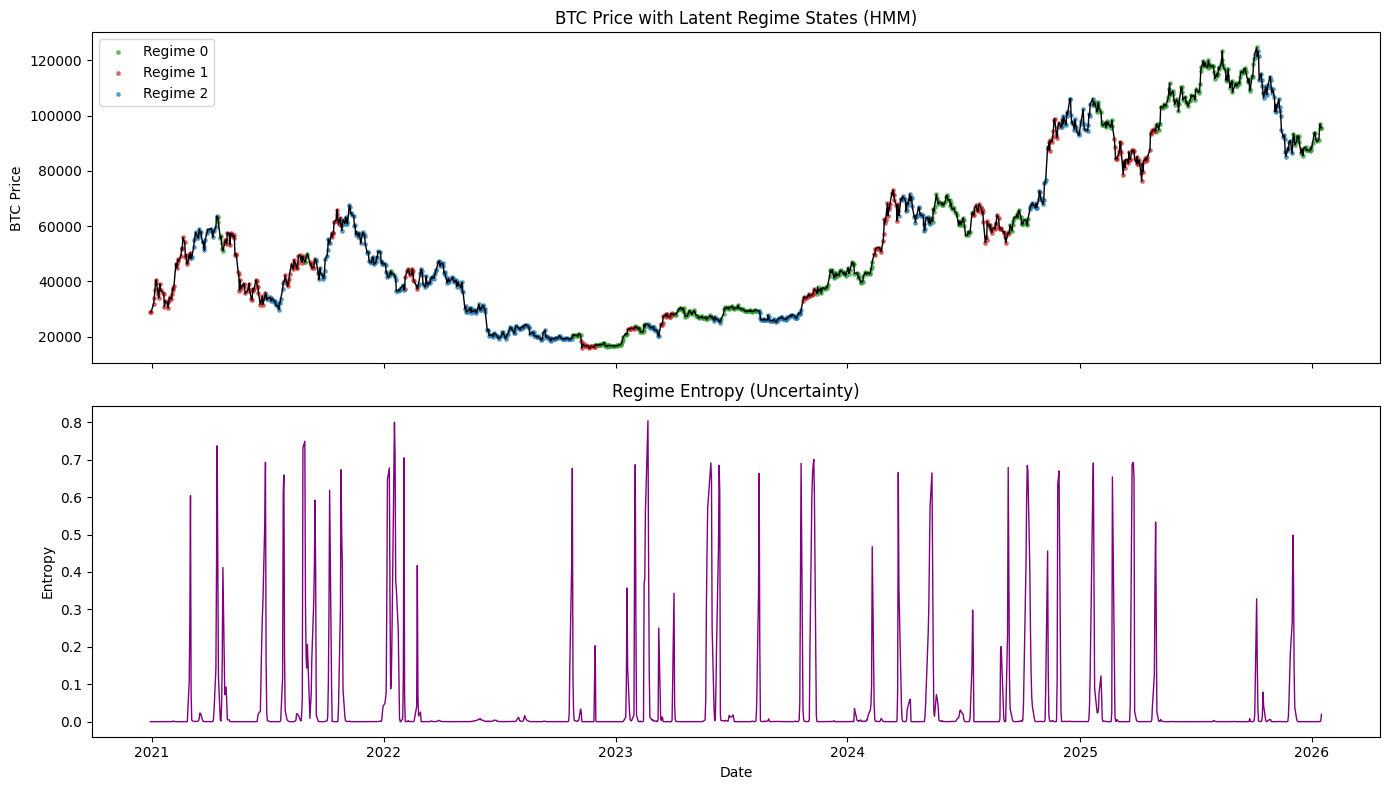

In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
base_path = "/Users/edmundobrown/Documents/MLGeral/AI-Finance/teste-cursor/crypto-mkt-state/data"

regime_path = f"{base_path}/04_cross_asset/l4_regime_states.parquet"
transition_path = f"{base_path}/04_cross_asset/l4_regime_transition_matrix.json"
btc_path = f"{base_path}/01_raw/crypto/binance/ohlcv_daily/BTCUSDT"

# -----------------------------
# Load data
# -----------------------------
regime = pd.read_parquet(regime_path)
btc = pd.read_parquet(btc_path)

with open(transition_path, "r") as f:
    transition = json.load(f)

# -----------------------------
# Ensure UTC on BOTH sides
# -----------------------------
# Regime is already UTC, but be explicit
regime["date"] = pd.to_datetime(regime["date"], utc=True)

# BTC: localize or convert
if btc["date"].dtype.tz is None:
    btc["date"] = pd.to_datetime(btc["date"]).dt.tz_localize("UTC")
else:
    btc["date"] = pd.to_datetime(btc["date"]).dt.tz_convert("UTC")

btc = btc.sort_values("date")
regime = regime.sort_values("date")

# -----------------------------
# Sanity checks
# -----------------------------
print("Regime distribution:")
print(regime["regime_state"].value_counts(normalize=True).sort_index())

print("\nTransition matrix:")
tm = pd.DataFrame(
    transition["transition_matrix"],
    columns=[f"to_{i}" for i in range(transition["n_states"])],
    index=[f"from_{i}" for i in range(transition["n_states"])],
)
display(tm)

print("\nRegime entropy:")
print(regime["regime_entropy"].describe())

# -----------------------------
# Merge price + regime
# -----------------------------
df = regime.merge(
    btc[["date", "close"]],
    on="date",
    how="left",
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# BTC price
ax[0].plot(df["date"], df["close"], color="black", linewidth=1)
ax[0].set_title("BTC Price with Latent Regime States (HMM)")
ax[0].set_ylabel("BTC Price")

colors = {0: "tab:green", 1: "tab:red", 2: "tab:blue"}
for state, color in colors.items():
    mask = df["regime_state"] == state
    ax[0].scatter(
        df.loc[mask, "date"],
        df.loc[mask, "close"],
        s=6,
        color=color,
        alpha=0.6,
        label=f"Regime {state}",
    )

ax[0].legend(loc="upper left")

# Entropy
ax[1].plot(df["date"], df["regime_entropy"], color="purple", linewidth=1)
ax[1].set_title("Regime Entropy (Uncertainty)")
ax[1].set_ylabel("Entropy")
ax[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


### Backtest simples:Estratégia:
 Long só em Regime 0, 
 flat/cash em 1 e 2 (ou short em 2 se alavancado).
 
Compare vs. buy & hold.



=== PERFORMANCE SUMMARY ===


,HMM Strategy,Buy & Hold
annual_return,0.234408,0.367171
annual_vol,0.276241,0.650961
sharpe,0.848564,0.564045
max_drawdown,-0.204502,-0.765102



Exposure breakdown (time in market):


position
0.0    0.647198
1.0    0.352802
Name: proportion, dtype: float64


Final equity:


strategy_equity    1.977159
buy_hold_equity    1.716449
Name: 1267, dtype: float64

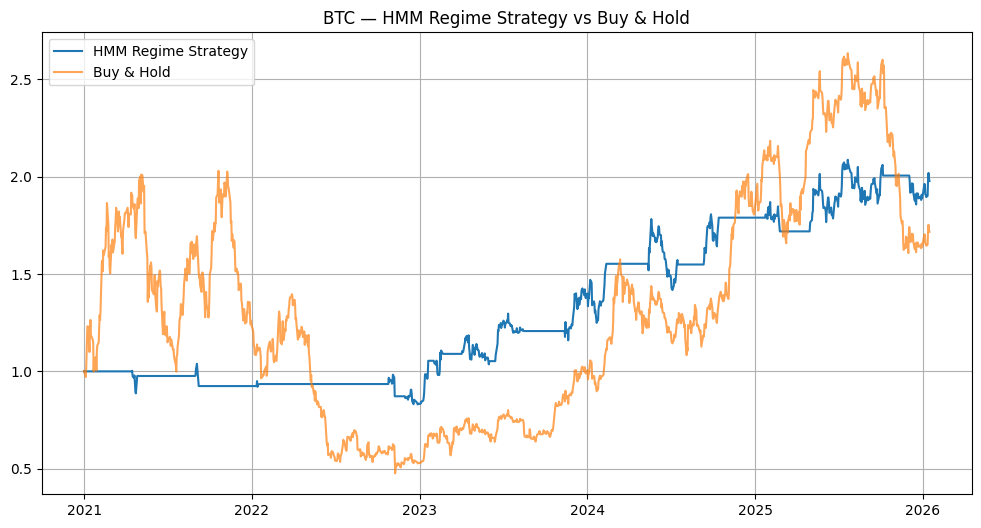

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load datasets (CORRETOS)
# --------------------------------------------------
regime = pd.read_parquet(
    "/Users/edmundobrown/Documents/MLGeral/AI-Finance/teste-cursor/crypto-mkt-state/data/04_cross_asset/l4_regime_states.parquet"
)

features = pd.read_parquet(
    "/Users/edmundobrown/Documents/MLGeral/AI-Finance/teste-cursor/crypto-mkt-state/data/04_cross_asset/l3_regime_features.parquet"
)

# --------------------------------------------------
# Normalize schema (date as column)
# --------------------------------------------------
if "date" not in regime.columns:
    regime = regime.reset_index()

if "date" not in features.columns:
    features = features.reset_index()

regime["date"] = pd.to_datetime(regime["date"], utc=True)
features["date"] = pd.to_datetime(features["date"], utc=True)

# --------------------------------------------------
# Merge BTC returns with regime
# --------------------------------------------------
df = (
    regime[["date", "regime_state"]]
    .merge(
        features[["date", "btc_return_1d"]],
        on="date",
        how="inner",
    )
    .sort_values("date")
    .reset_index(drop=True)
)

# --------------------------------------------------
# Strategy definition
# --------------------------------------------------
df["position"] = 0.0
df.loc[df["regime_state"] == 0, "position"] = 1.0      # long
# df.loc[df["regime_state"] == 2, "position"] = -1.0   # optional short

# --------------------------------------------------
# Returns (NO LOOKAHEAD)
# --------------------------------------------------
df["strategy_return"] = df["position"].shift(1) * df["btc_return_1d"]
df["buy_hold_return"] = df["btc_return_1d"]

df = df.dropna()

# --------------------------------------------------
# Equity curves
# --------------------------------------------------
df["strategy_equity"] = (1 + df["strategy_return"]).cumprod()
df["buy_hold_equity"] = (1 + df["buy_hold_return"]).cumprod()

# --------------------------------------------------
# Performance metrics
# --------------------------------------------------
def perf_stats(returns: pd.Series):
    ann_factor = 365
    mu = returns.mean() * ann_factor
    vol = returns.std() * np.sqrt(ann_factor)
    sharpe = mu / vol if vol > 0 else np.nan
    dd = (1 + returns).cumprod()
    max_dd = (dd / dd.cummax() - 1).min()
    return pd.Series({
        "annual_return": mu,
        "annual_vol": vol,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
    })

stats = pd.concat(
    [
        perf_stats(df["strategy_return"]).rename("HMM Strategy"),
        perf_stats(df["buy_hold_return"]).rename("Buy & Hold"),
    ],
    axis=1,
)

print("=== PERFORMANCE SUMMARY ===")
display(stats)

# --------------------------------------------------
# Exposure diagnostics
# --------------------------------------------------
print("\nExposure breakdown (time in market):")
display(df["position"].value_counts(normalize=True))

print("\nFinal equity:")
display(df[["strategy_equity", "buy_hold_equity"]].iloc[-1])

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["strategy_equity"], label="HMM Regime Strategy")
plt.plot(df["date"], df["buy_hold_equity"], label="Buy & Hold", alpha=0.7)
plt.legend()
plt.title("BTC — HMM Regime Strategy vs Buy & Hold")
plt.grid(True)
plt.show()


In [40]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# Paths L4 (FULL PATHS)
# ------------------------------------------------------------------
path_states = "/Users/edmundobrown/Documents/MLGeral/AI-Finance/teste-cursor/crypto-mkt-state/data/04_cross_asset/l4_regime_states_enriched.parquet"
path_cross = "/Users/edmundobrown/Documents/MLGeral/AI-Finance/teste-cursor/crypto-mkt-state/data/04_cross_asset/cross_asset_features.parquet"

# ------------------------------------------------------------------
# Load
# ------------------------------------------------------------------
states = pd.read_parquet(path_states)
cross = pd.read_parquet(path_cross)

print("=== L4 REGIME STATES (ENRICHED) ===")
print("Shape:", states.shape)
print("Columns:", states.columns.tolist())

# ------------------------------------------------------------------
# 1) Normalize date columns to UTC (CRITICAL FIX)
# ------------------------------------------------------------------
states["date"] = pd.to_datetime(states["date"], utc=True)

# cross_asset_features may be naive → force UTC
cross["date"] = pd.to_datetime(cross["date"], utc=True)

# ------------------------------------------------------------------
# 2) Presence checks
# ------------------------------------------------------------------
assert "regime_entropy" in states.columns, "❌ regime_entropy missing in l4_regime_states_enriched"
assert "regime_entropy" in cross.columns, "❌ regime_entropy missing in cross_asset_features"

# ------------------------------------------------------------------
# 3) Entropy sanity
# ------------------------------------------------------------------
entropy = states["regime_entropy"]

print("\n[Entropy summary]")
print(entropy.describe())

print("\n[Entropy checks]")
print("Min >= 0:", entropy.min() >= 0)
print("NaN count:", entropy.isna().sum())

# Theoretical max entropy = log(K)
p_cols = [c for c in states.columns if c.startswith("p_state_")]
K = len(p_cols)
print(f"Observed max entropy: {entropy.max():.4f}")
print(f"Theoretical max log(K={K}): {np.log(K):.4f}")

# ------------------------------------------------------------------
# 4) Entropy vs confidence
# ------------------------------------------------------------------
states["max_state_prob"] = states[p_cols].max(axis=1)
corr = states[["regime_entropy", "max_state_prob"]].corr().iloc[0, 1]
print("\nCorrelation entropy vs max_state_prob:", round(corr, 3))

# Expect strong NEGATIVE correlation

# ------------------------------------------------------------------
# 5) Alignment check (FIXED MERGE)
# ------------------------------------------------------------------
merged = cross.merge(
    states[["date", "regime_entropy"]],
    on="date",
    how="left",
    suffixes=("", "_states"),
)

diff = (merged["regime_entropy"] - merged["regime_entropy_states"]).abs().max()
print("\nMax abs diff entropy (states vs cross):", diff)

# ------------------------------------------------------------------
# 6) Final sample
# ------------------------------------------------------------------
print("\n[Sample tail]")
display(
    states[["date", "regime_state", "regime_entropy", "max_state_prob"]]
    .sort_values("date")
    .tail(10)
)


=== L4 REGIME STATES (ENRICHED) ===
Shape: (1268, 6)
Columns: ['date', 'regime_state', 'p_state_0', 'p_state_1', 'p_state_2', 'regime_entropy']

[Entropy summary]
count    1.268000e+03
mean     5.187271e-02
std      1.473517e-01
min      5.526204e-11
25%      3.382195e-05
50%      2.567202e-04
75%      5.152220e-03
max      8.042856e-01
Name: regime_entropy, dtype: float64

[Entropy checks]
Min >= 0: True
NaN count: 0
Observed max entropy: 0.8043
Theoretical max log(K=3): 1.0986

Correlation entropy vs max_state_prob: -0.96

Max abs diff entropy (states vs cross): 0.0

[Sample tail]


,date,regime_state,regime_entropy,max_state_prob
1258,2026-01-05 00:00:00+00:00,0,0.000011,0.999999
1259,2026-01-06 00:00:00+00:00,0,0.000009,0.999999
1260,2026-01-07 00:00:00+00:00,0,0.000020,0.999999
1261,2026-01-08 00:00:00+00:00,0,0.000038,0.999997
1262,2026-01-09 00:00:00+00:00,0,0.000118,0.999991
1263,2026-01-12 00:00:00+00:00,0,0.000027,0.999998
1264,2026-01-13 00:00:00+00:00,0,0.000419,0.999965
1265,2026-01-14 00:00:00+00:00,0,0.000461,0.999960
1266,2026-01-15 00:00:00+00:00,0,0.003439,0.999616
1267,2026-01-16 00:00:00+00:00,0,0.019689,0.997231
